# Predictive Forecasting of Care Load & Placement Demand

# Notebook 03 – Exploratory Data Analysis (EDA)

## Business Objective

Before building forecasting models, we need to understand historical trends, seasonal patterns, relationships between variables, and potential anomalies in the UAC dataset.

The insights generated in this notebook will help government stakeholders understand operational behavior and prepare the dataset for predictive forecasting.

# Business Questions

This notebook aims to answer the following questions:

1. Is the number of children in HHS Care increasing or decreasing over time?

2. How has CBP custody changed over time?

3. Are transfers from CBP keeping pace with new apprehensions?

4. Are discharge numbers increasing?

5. Are there seasonal or recurring patterns?

6. Which variables are strongly correlated?

7. Are there unusual spikes or outliers?

8. What insights can help HHS plan resources more effectively?

In [23]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

%matplotlib inline

In [24]:
df = pd.read_csv("../data/processed/HHS_UAC_Cleaned.csv")

In [25]:
df["Date"] = pd.to_datetime(df["Date"])

In [26]:
df.head()

,Date,Children apprehended and placed in CBP custody*,Children in CBP custody,Children transferred out of CBP custody,Children in HHS Care,Children discharged from HHS Care
0,2025-12-21,6.0,18.0,11.0,2484,14.0
1,2025-12-18,11.0,50.0,6.0,2472,16.0
2,2025-12-17,7.0,31.0,11.0,2481,10.0
3,2025-12-16,8.0,54.0,15.0,2468,9.0
4,2025-12-15,11.0,42.0,9.0,2470,7.0


In [27]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 720 entries, 0 to 719
Data columns (total 6 columns):
 #   Column                                           Non-Null Count  Dtype         
---  ------                                           --------------  -----         
 0   Date                                             720 non-null    datetime64[us]
 1   Children apprehended and placed in CBP custody*  720 non-null    float64       
 2   Children in CBP custody                          720 non-null    float64       
 3   Children transferred out of CBP custody          720 non-null    float64       
 4   Children in HHS Care                             720 non-null    int64         
 5   Children discharged from HHS Care                720 non-null    float64       
dtypes: datetime64[us](1), float64(4), int64(1)
memory usage: 33.9 KB


### Dataset Overview

- Total observations: 720
- Date Range: January 2023 – December 2025
- Variables: 6
- Reporting Frequency: Daily

# Business Question 1

## Is the number of children in HHS Care increasing or decreasing over time?

In [28]:
df = df.sort_values("Date")

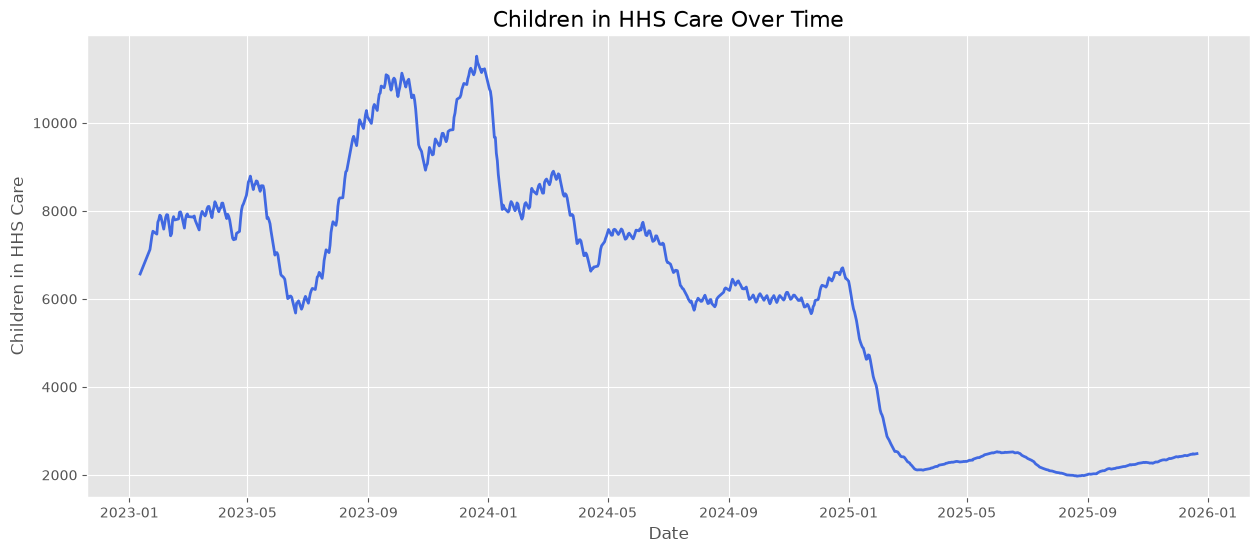

In [29]:
plt.figure(figsize=(15,6))

plt.plot(
    df["Date"],
    df["Children in HHS Care"],
    color="royalblue",
    linewidth=2
)

plt.title("Children in HHS Care Over Time", fontsize=16)
plt.xlabel("Date")
plt.ylabel("Children in HHS Care")
plt.grid(True)

plt.show()

Business Insight

The line chart illustrates how the number of children in HHS Care has changed over time.

Periods of rapid increase may indicate higher border arrivals or policy changes, while declining periods suggest increased discharges or reduced apprehensions.

These trends help HHS forecast shelter capacity and staffing requirements.

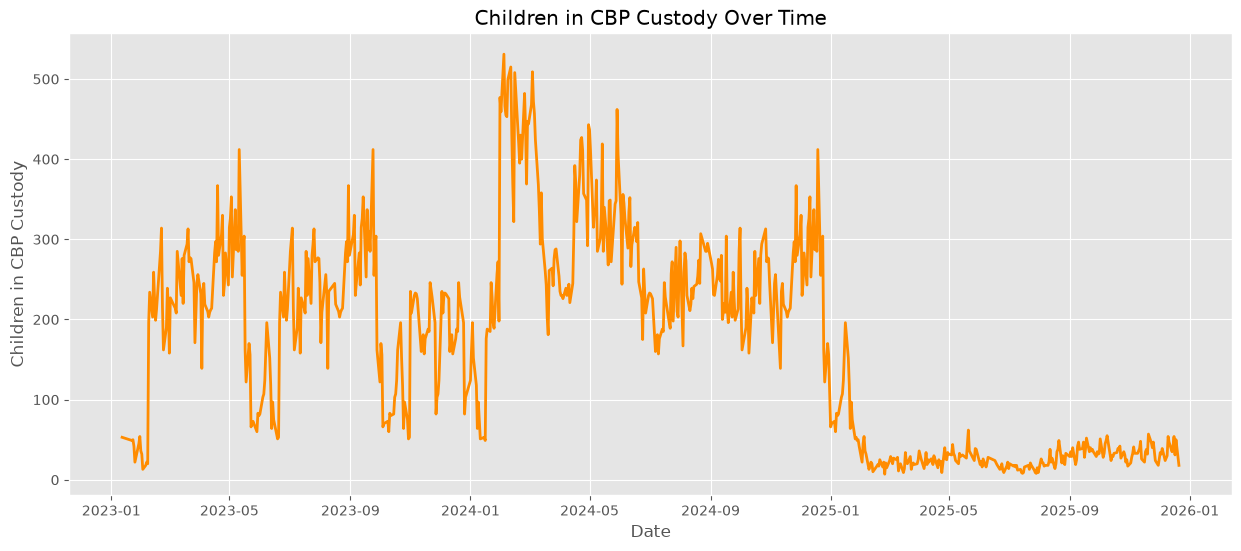

In [30]:
plt.figure(figsize=(15,6))

plt.plot(
    df["Date"],
    df["Children in CBP custody"],
    color="darkorange",
    linewidth=2
)

plt.title("Children in CBP Custody Over Time")
plt.xlabel("Date")
plt.ylabel("Children in CBP Custody")
plt.grid(True)

plt.show()

The number of children in CBP custody fluctuates across the observed period.

Large spikes may indicate temporary surges at the border before transfers into HHS Care.

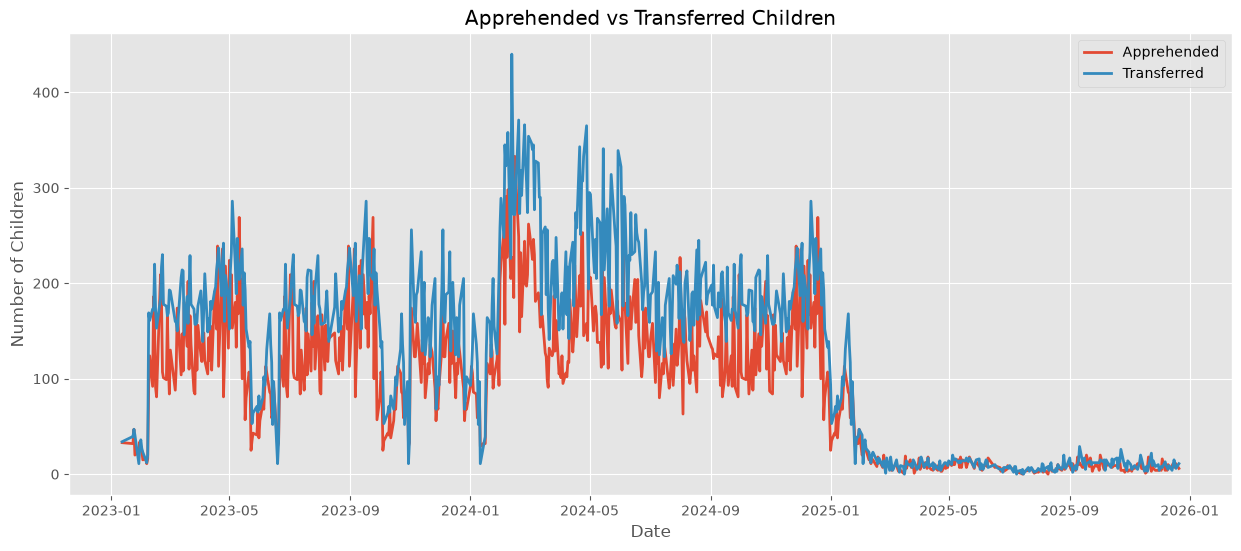

In [31]:
plt.figure(figsize=(15,6))

plt.plot(
    df["Date"],
    df["Children apprehended and placed in CBP custody*"],
    label="Apprehended",
    linewidth=2
)

plt.plot(
    df["Date"],
    df["Children transferred out of CBP custody"],
    label="Transferred",
    linewidth=2
)

plt.legend()

plt.title("Apprehended vs Transferred Children")
plt.xlabel("Date")
plt.ylabel("Number of Children")

plt.grid(True)

plt.show()

Comparing apprehensions with transfers helps identify operational bottlenecks.

When transfers consistently lag behind apprehensions, overcrowding in CBP facilities may occur.

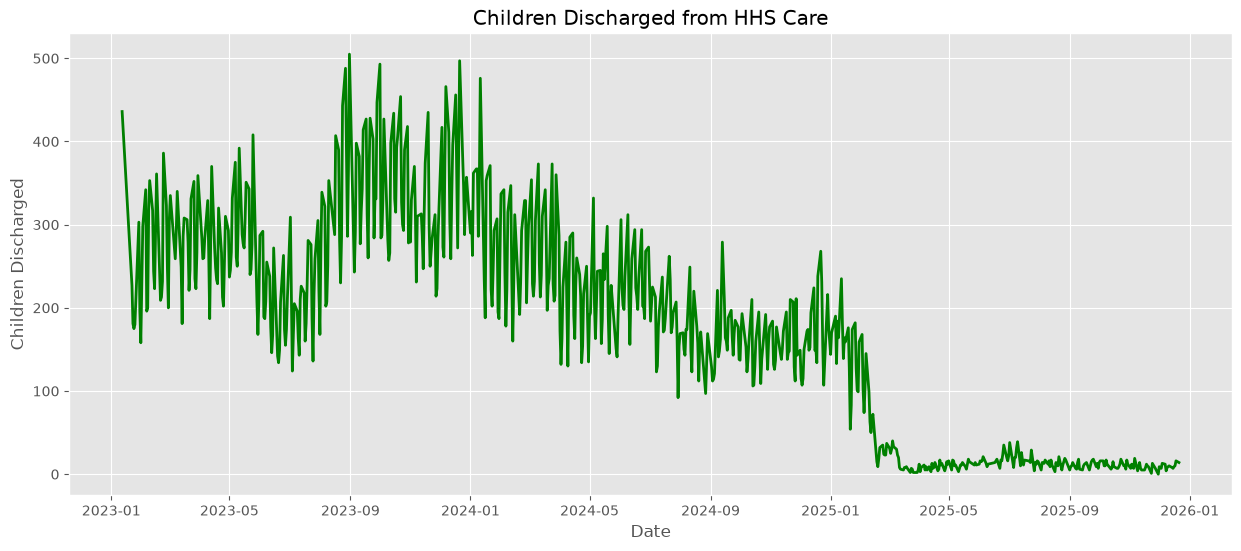

In [32]:
plt.figure(figsize=(15,6))

plt.plot(
    df["Date"],
    df["Children discharged from HHS Care"],
    color="green",
    linewidth=2
)

plt.title("Children Discharged from HHS Care")
plt.xlabel("Date")
plt.ylabel("Children Discharged")

plt.grid(True)

plt.show()

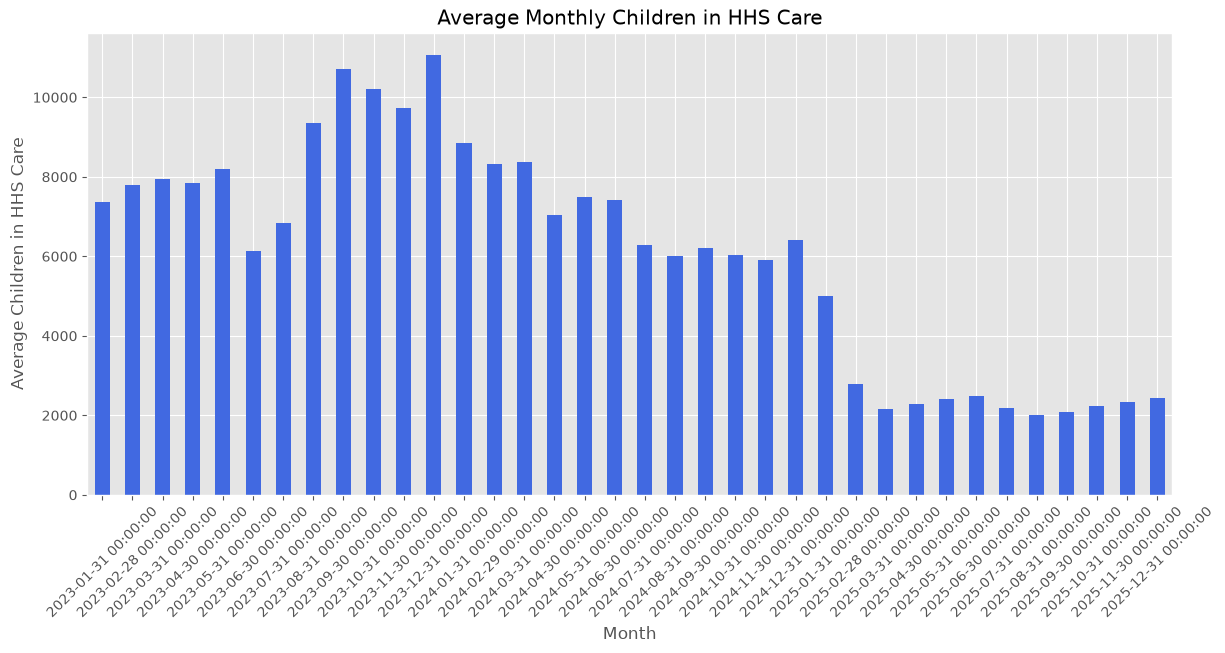

In [33]:
monthly = df.resample("ME", on="Date")["Children in HHS Care"].mean()

plt.figure(figsize=(14,6))

monthly.plot(kind="bar", color="royalblue")

plt.title("Average Monthly Children in HHS Care")
plt.xlabel("Month")
plt.ylabel("Average Children in HHS Care")

plt.xticks(rotation=45)

plt.show()

### Business Insight

Monthly averages remove short-term fluctuations and highlight long-term changes in care demand.

Higher monthly averages suggest sustained operational pressure on HHS facilities, while declining averages may indicate improved discharge efficiency or reduced intake volumes.

These insights assist decision-makers in workforce planning and shelter capacity management.

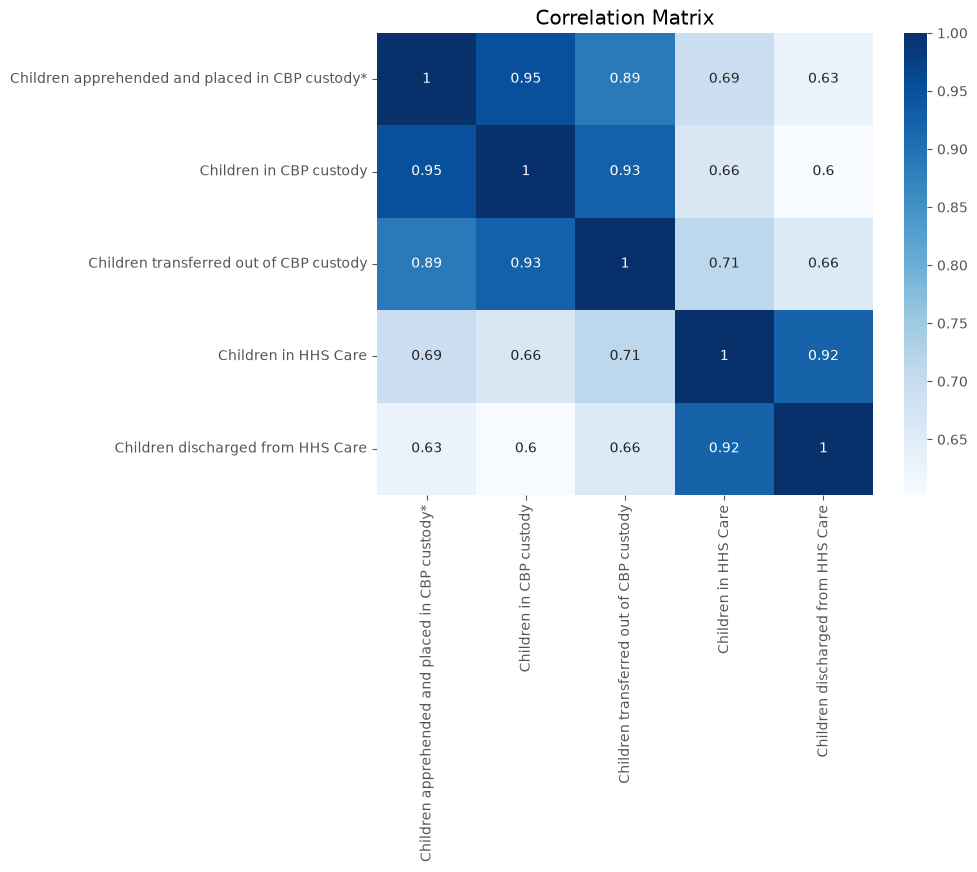

In [34]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    cmap="Blues"
)

plt.title("Correlation Matrix")

plt.show()

### Business Insight

The correlation matrix highlights the strength and direction of relationships among operational variables.

Strong positive correlations suggest variables that move together, whereas weak correlations indicate relatively independent behavior.

These findings support feature selection and improve forecasting model performance.

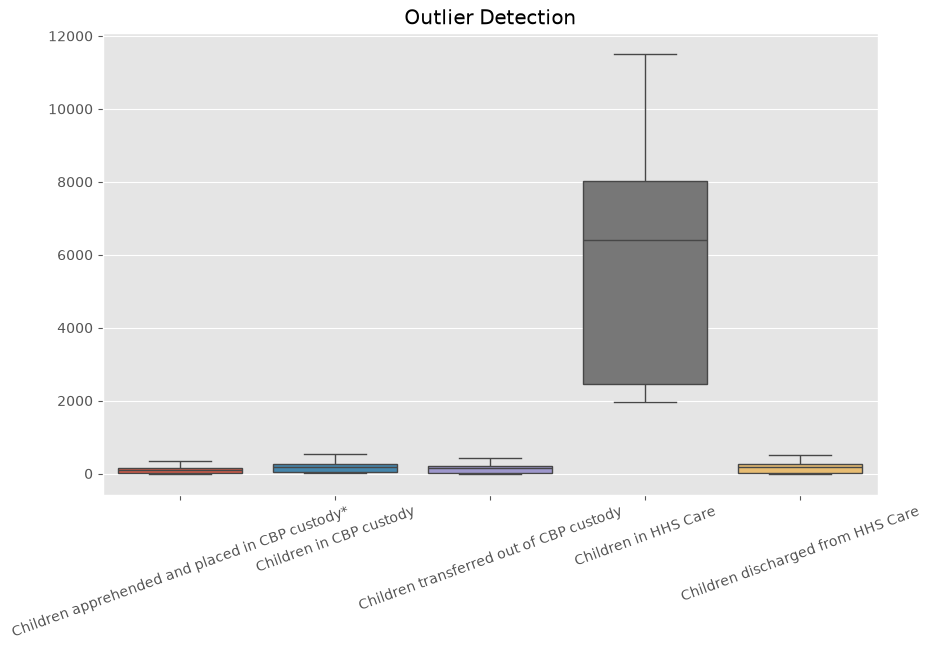

In [35]:
plt.figure(figsize=(10,6))

sns.boxplot(data=df.drop(columns=["Date"]))

plt.xticks(rotation=20)

plt.title("Outlier Detection")

plt.show()

### Business Insight

The box plot identifies unusual observations that deviate substantially from the typical operational range.

These outliers may represent significant real-world events requiring further investigation rather than simple data errors.

Recognizing these events improves forecasting accuracy and operational awareness.

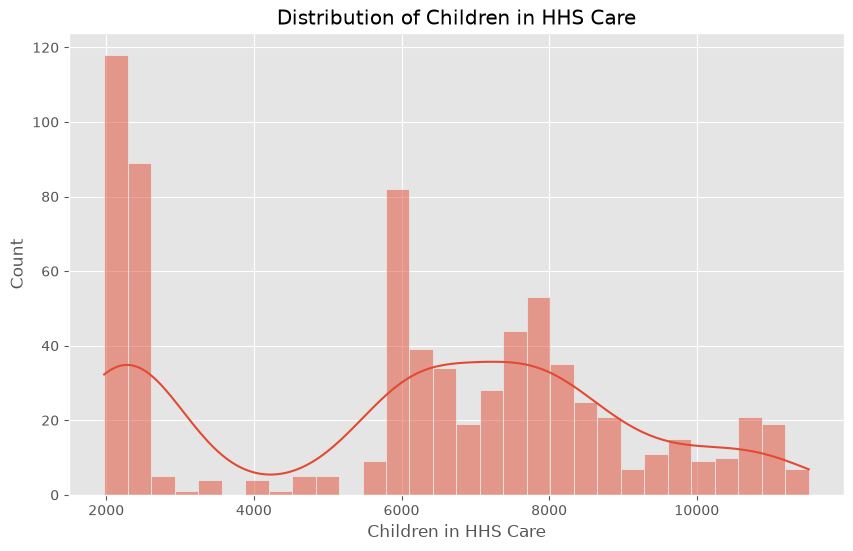

In [36]:
plt.figure(figsize=(10,6))

sns.histplot(
    df["Children in HHS Care"],
    bins=30,
    kde=True
)

plt.title("Distribution of Children in HHS Care")

plt.show()

### Business Insight

The histogram illustrates the frequency distribution of children in HHS Care across the reporting period.

The overall shape of the distribution provides insight into variability, concentration of observations, and potential skewness.

Understanding the distribution supports appropriate model selection and statistical assumptions.

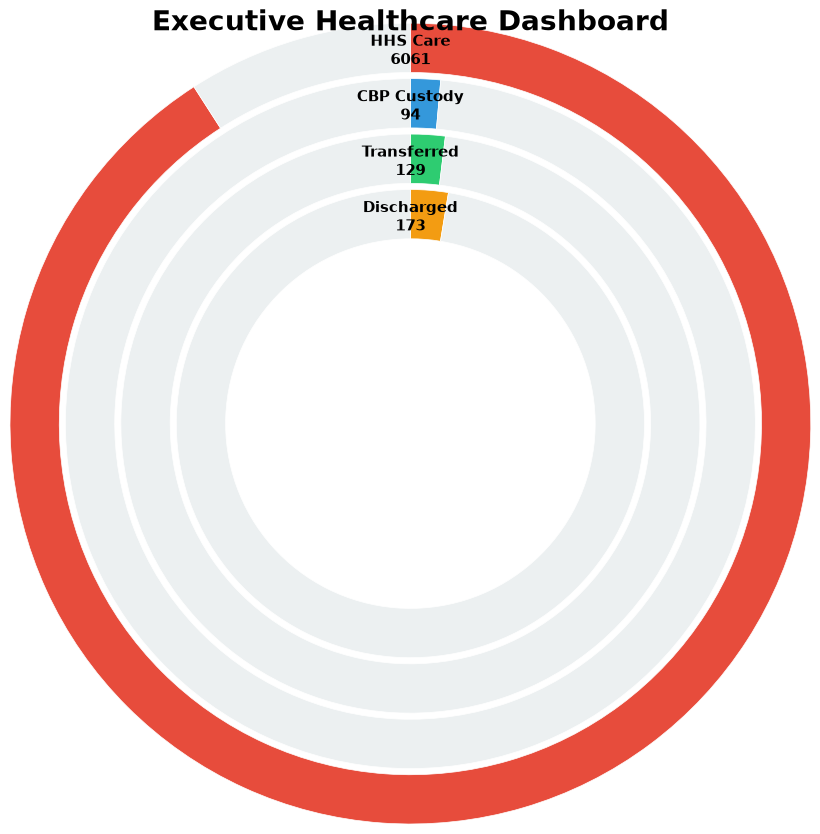

In [37]:
import matplotlib.pyplot as plt

# Average values
hhs = df["Children in HHS Care"].mean()
cbp = df["Children apprehended and placed in CBP custody*"].mean()
transfer = df["Children transferred out of CBP custody"].mean()
discharge = df["Children discharged from HHS Care"].mean()

fig, ax = plt.subplots(figsize=(10,10))

colors = ["#e74c3c","#3498db","#2ecc71","#f39c12"]

rings = [
    ("HHS Care", hhs),
    ("CBP Custody", cbp),
    ("Transferred", transfer),
    ("Discharged", discharge)
]

radius = 1.3
width = 0.18

for i,(label,value) in enumerate(rings):

    ax.pie(
        [value, max(hhs,value)*1.1-value],
        radius=radius-i*width,
        startangle=90,
        colors=[colors[i],"#ecf0f1"],
        counterclock=False,
        wedgeprops=dict(width=width-0.02,
                        edgecolor="white")
    )

    ax.text(
        0,
        radius-i*width-width/2,
        f"{label}\n{value:.0f}",
        ha="center",
        va="center",
        fontsize=11,
        fontweight="bold"
    )

ax.set(aspect="equal")
plt.title(
    "Executive Healthcare Dashboard",
    fontsize=20,
    fontweight="bold"
)

plt.show()

### Business Insight

The dashboard highlights that the majority of operational demand is concentrated in **Children in HHS Care**, which represents the largest workload across the dataset. Compared with the number of children currently receiving care, the average number of new CBP placements, transfers, and discharges is relatively small.

This indicates that children typically remain in HHS care for a longer period, causing the active care population to accumulate over time. As a result, HHS requires sustained staffing, shelter capacity, healthcare resources, and long-term operational planning rather than focusing only on daily arrivals.

The relatively low transfer and discharge volumes suggest that children are leaving the care system at a slower rate than they are being supported, reinforcing the importance of forecasting future care demand.

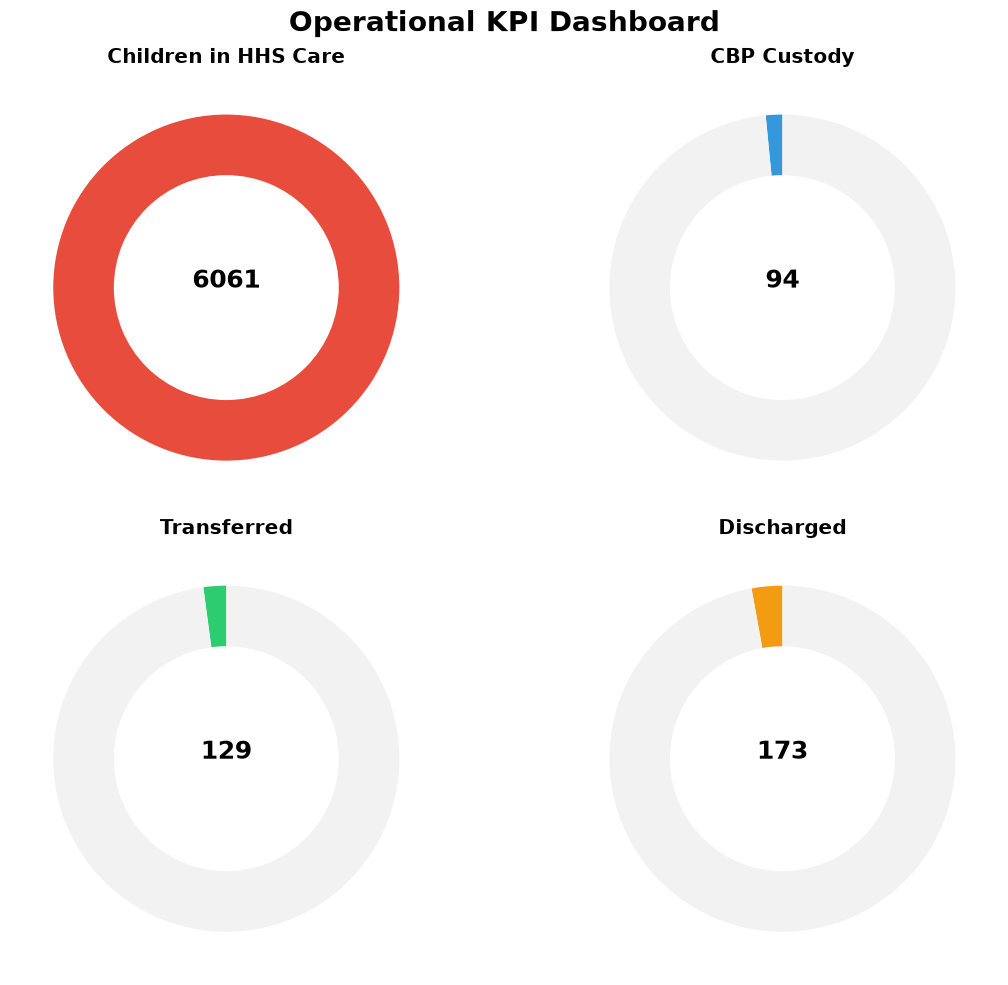

In [38]:
fig,axs = plt.subplots(2,2,figsize=(12,10))

titles = [
    "Children in HHS Care",
    "CBP Custody",
    "Transferred",
    "Discharged"
]

values = [
    hhs,
    cbp,
    transfer,
    discharge
]

colors = [
    "#e74c3c",
    "#3498db",
    "#2ecc71",
    "#f39c12"
]

for ax,title,value,color in zip(axs.flat,titles,values,colors):

    ax.pie(
        [value,max(values)-value],
        startangle=90,
        colors=[color,"#f2f2f2"],
        wedgeprops=dict(width=0.35)
    )

    ax.text(
        0,
        0,
        f"{value:.0f}",
        ha="center",
        fontsize=18,
        fontweight="bold"
    )

    ax.set_title(title,fontweight="bold")

plt.suptitle(
    "Operational KPI Dashboard",
    fontsize=20,
    fontweight="bold"
)

plt.tight_layout()

plt.show()

### Business Insight

The KPI dashboard shows a significant imbalance between the number of children in active HHS care and the daily operational activities such as CBP placements, transfers, and discharges.

This pattern suggests that the HHS program operates primarily as a long-term care system rather than a short-term processing system. Since the active care population remains substantially higher than incoming or outgoing movements, resource utilization is driven mainly by maintaining existing care capacity.

These findings emphasize the need for accurate forecasting models to anticipate future occupancy levels, optimize shelter utilization, allocate staffing efficiently, and improve long-term operational planning.

### Overall Conclusion

The visual analysis indicates that Children in HHS Care consistently represents the largest operational component of the UAC program. Daily admissions, transfers, and discharges contribute only a small portion of overall activity, suggesting that children remain in care for extended periods.

These findings support the need for predictive forecasting models that can estimate future care demand, improve capacity planning, and help HHS allocate resources proactively while maintaining high-quality care for unaccompanied children.

# Final EDA Summary

## Key Findings

The Exploratory Data Analysis (EDA) revealed several important operational patterns within the HHS Unaccompanied Alien Children (UAC) dataset.

- The number of children currently in HHS Care is consistently much higher than the number of daily CBP apprehensions, transfers, and discharges.
- Monthly trends indicate fluctuations in care demand, highlighting periods of increased operational workload.
- Correlation analysis shows strong relationships among operational variables, suggesting that changes in one stage of the care process influence others.
- Distribution and outlier analysis identified several unusual spikes that may correspond to policy changes, migration surges, or seasonal events.
- Overall operational activity is dominated by the active HHS care population, emphasizing the importance of long-term resource planning.

## Business Recommendation

Based on these findings, forecasting models should focus primarily on predicting future HHS Care occupancy. Accurate forecasts can help decision-makers optimize shelter capacity, staffing, budgeting, and healthcare resource allocation while improving preparedness for sudden increases in demand.

The cleaned dataset is now ready for feature engineering and predictive forecasting.